# 11 — Refined robustness

Attack the new findings: strict / weighted / inclusive coding, author concentration,
headline components, and OLD TAXONOMY | REFINED STRICT | REFINED WEIGHTED panels.
Thin single-topic effects (e.g. H4 protection) are flagged explicitly.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

cwd = Path.cwd().resolve()
root = cwd
for _ in range(6):
    if (root / "configs").is_dir() and (root / "src").is_dir():
        break
    root = root.parent
sys.path.insert(0, str(root))

from src.stage11_refined_construct_analysis.analysis import notebook_helpers as nh

ctx = nh.setup("11_refined_robustness")
cfg = ctx.cfg
GATE = nh.effect_gate(cfg)
delta_freeze = cfg.section("stage10_delta_freeze")
coverage = nh.load_construct_coverage(cfg)

Project root : /home/polina/Documents/Cursor_Projects/romantic_novels_large_corpus
Config       : configs/stage11/refined_constructs.yaml
Run          : v4_l12_granular_final_call49
Outputs      : results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/11_refined_robustness


In [2]:
features = [
    # Primary ratios / composites
    "RLR_emotional_vs_explicit",
    "RAX_h2_strict",
    "RLR_emotional_vs_material_security",
    "RLR_protection_vs_control",
    "RLR_darkness_vs_tenderness",
    "RARC",
    # Headline components
    "RAX_explicit_sex",
    "RAX_nonexplicit_affection",
    "RAX_appearance_grooming",
    "RAX_status_display",
    "RAX_external_danger_crisis",
    "RAX_h4_protection_side",
    "RAX_external_protection",
    "RAX_protective_commitment",
    "RAX_protective_care_broad",
    "RAX_relational_darkness",
    "RAX_tenderness_core",
]

panels = []
for mode in ("strict", "weighted", "inclusive"):
    frame = nh.load_refined_frame(cfg, mode)
    usable = frame[frame["analysable"].fillna(True)] if "analysable" in frame.columns else frame
    cols = [c for c in features if c in usable.columns]
    eff = nh.cliffs_delta_table(usable, cols, n_boot=300, seed=42)
    eff["mode"] = mode
    eff["measurement_gate"] = eff["feature"].map(
        lambda f: nh.gate_for_feature(coverage, f)
    )
    panels.append(eff)

    if "author_id" in usable.columns:
        counts = usable.groupby("author_id").size()
        singletons = counts[counts == 1].index
        sub = usable[usable["author_id"].isin(singletons)]
        if len(sub) > 200:
            eff_s = nh.cliffs_delta_table(sub, cols, n_boot=200, seed=42)
            eff_s["mode"] = f"{mode}_singleton"
            eff_s["measurement_gate"] = eff_s["feature"].map(
                lambda f: nh.gate_for_feature(coverage, f)
            )
            panels.append(eff_s)

panel = pd.concat(panels, ignore_index=True)
panel["verdict"] = [
    nh.gated_verdict(
        r.cliffs_delta,
        r.ci_low,
        r.ci_high,
        measurement_gate=r.measurement_gate,
        effect_gate=GATE,
    )
    for r in panel.itertuples()
]
display(panel.round(4))
ctx.save_table(panel, "robustness_panel")

,feature,cliffs_delta,ci_low,ci_high,magnitude,n_high,n_low,mean_high,mean_low,mode,measurement_gate,verdict
0,RLR_emotional_vs_explicit,0.0564,0.0329,0.0796,negligible,5086,5389,9.5786,9.4971,strict,unmeasurable,unmeasurable
1,RAX_h2_strict,0.0000,0.0000,0.0000,negligible,5086,5389,0.0000,0.0000,strict,unmeasurable,unmeasurable
2,RLR_emotional_vs_material_security,0.0726,0.0492,0.0951,negligible,5086,5389,10.2993,10.2408,strict,unmeasurable,unmeasurable
3,RLR_protection_vs_control,0.0898,0.0698,0.1108,negligible,5086,5389,0.5098,0.3532,strict,thin,thin:directional_only
4,RLR_darkness_vs_tenderness,-0.0184,-0.0402,0.0017,negligible,5086,5389,1.7763,1.7907,strict,thin,thin:no reliable effect
...,...,...,...,...,...,...,...,...,...,...,...,...
97,RAX_external_protection,0.1367,0.1023,0.1806,small,1561,2190,0.0030,0.0025,inclusive_singleton,thin,thin:clears_gate
98,RAX_protective_commitment,0.0000,0.0000,0.0000,negligible,1561,2190,0.0000,0.0000,inclusive_singleton,unmeasurable,unmeasurable
99,RAX_protective_care_broad,0.1367,0.1023,0.1691,small,1561,2190,0.0030,0.0025,inclusive_singleton,thin,thin:clears_gate
100,RAX_relational_darkness,0.0376,0.0036,0.0825,negligible,1561,2190,0.0667,0.0661,inclusive_singleton,viable,directional_only


  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/11_refined_robustness/tables/robustness_panel.csv  (102 rows)


## Thin-effect flags (single-topic / weak coverage)

In [3]:
thin = panel[
    (panel["mode"] == "strict")
    & (panel["measurement_gate"].isin(["thin", "unmeasurable"]))
][
    ["feature", "measurement_gate", "cliffs_delta", "ci_low", "ci_high", "verdict"]
]
display(thin)
ctx.save_table(thin, "thin_or_unmeasurable_effects")
print(
    "Do not generalise thin effects (e.g. single-topic external protection) "
    "as construct-level findings."
)

,feature,measurement_gate,cliffs_delta,ci_low,ci_high,verdict
0,RLR_emotional_vs_explicit,unmeasurable,0.0564,0.0329,0.0796,unmeasurable
1,RAX_h2_strict,unmeasurable,0.0000,0.0000,0.0000,unmeasurable
2,RLR_emotional_vs_material_security,unmeasurable,0.0726,0.0492,0.0951,unmeasurable
3,RLR_protection_vs_control,thin,0.0898,0.0698,0.1108,thin:directional_only
4,RLR_darkness_vs_tenderness,thin,-0.0184,-0.0402,0.0017,thin:no reliable effect
6,RAX_explicit_sex,unmeasurable,0.0000,0.0000,0.0000,unmeasurable
7,RAX_nonexplicit_affection,thin,0.0405,0.0200,0.0670,thin:directional_only
9,RAX_status_display,unmeasurable,0.0000,0.0000,0.0000,unmeasurable
11,RAX_h4_protection_side,thin,0.1597,0.1389,0.1813,thin:clears_gate
12,RAX_external_protection,thin,0.1597,0.1398,0.1789,thin:clears_gate


  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/11_refined_robustness/tables/thin_or_unmeasurable_effects.csv  (13 rows)
Do not generalise thin effects (e.g. single-topic external protection) as construct-level findings.


## Old taxonomy | Refined strict | Refined weighted

This figure compares the original broad taxonomy measurement with the contextually validated
replacements. The old and refined δ values measure somewhat different constructs, so they
are **not directly commensurable** — the figure shows how *conclusions* change, not how
effect sizes replicate.

Key shifts: H1 moves from −0.029 to +0.099; H5 from +0.012 to −0.031; H6 from +0.044 to
−0.053. H2 and H3 become unmeasurable under strict semantic refinement.

In [4]:
hyp_map = {
    "H1": ("RLR_emotional_vs_explicit", "H1"),
    "H2": ("RAX_h2_strict", "H2"),
    "H3": ("RLR_emotional_vs_material_security", "H3"),
    "H4": ("RLR_protection_vs_control", "H4"),
    "H5": ("RLR_darkness_vs_tenderness", "H5"),
    "H6": ("RARC", "H6"),
}
rows = []
for hyp, (feat, freeze_key) in hyp_map.items():
    old = delta_freeze.get(freeze_key)
    for mode in ("strict", "weighted"):
        sub = panel[(panel["mode"] == mode) & (panel["feature"] == feat)]
        rows.append(
            {
                "hypothesis": hyp,
                "spec": f"refined_{mode}",
                "cliffs_delta": float(sub.iloc[0]["cliffs_delta"]) if len(sub) else np.nan,
                "measurement_gate": sub.iloc[0]["measurement_gate"] if len(sub) else "missing",
            }
        )
    rows.append(
        {
            "hypothesis": hyp,
            "spec": "old_taxonomy",
            "cliffs_delta": old,
            "measurement_gate": "stage10",
        }
    )
compare = pd.DataFrame(rows)
wide = compare.pivot(index="hypothesis", columns="spec", values="cliffs_delta")
display(wide)
ctx.save_table(wide.reset_index(), "old_vs_refined_panel")

# Component headline panel
comp_feats = [
    "RAX_explicit_sex",
    "RAX_appearance_grooming",
    "RAX_external_danger_crisis",
    "RAX_h4_protection_side",
]
comp_panel = panel[
    (panel["mode"] == "strict") & (panel["feature"].isin(comp_feats))
][
    ["feature", "cliffs_delta", "ci_low", "ci_high", "measurement_gate", "verdict"]
]
display(comp_panel.round(4))
ctx.save_table(comp_panel, "headline_component_effects")

spec,old_taxonomy,refined_strict,refined_weighted
hypothesis,,,
H1,-0.0290,0.0564,0.0565
H2,0.0270,0.0000,0.0330
H3,-0.1460,0.0726,0.0315
H4,0.0900,0.0898,0.0898
H5,0.0120,-0.0184,-0.0194
H6,0.0440,-0.0528,-0.0528


  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/11_refined_robustness/tables/old_vs_refined_panel.csv  (6 rows)


,feature,cliffs_delta,ci_low,ci_high,measurement_gate,verdict
6,RAX_explicit_sex,0.0000,0.0000,0.0000,unmeasurable,unmeasurable
8,RAX_appearance_grooming,-0.1424,-0.1669,-0.1205,viable,clears_gate
10,RAX_external_danger_crisis,0.1159,0.0964,0.1340,viable,clears_gate
11,RAX_h4_protection_side,0.1597,0.1389,0.1813,thin,thin:clears_gate


  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/11_refined_robustness/tables/headline_component_effects.csv  (4 rows)


  saved figure: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/11_refined_robustness/figures/old_vs_refined_bars.png


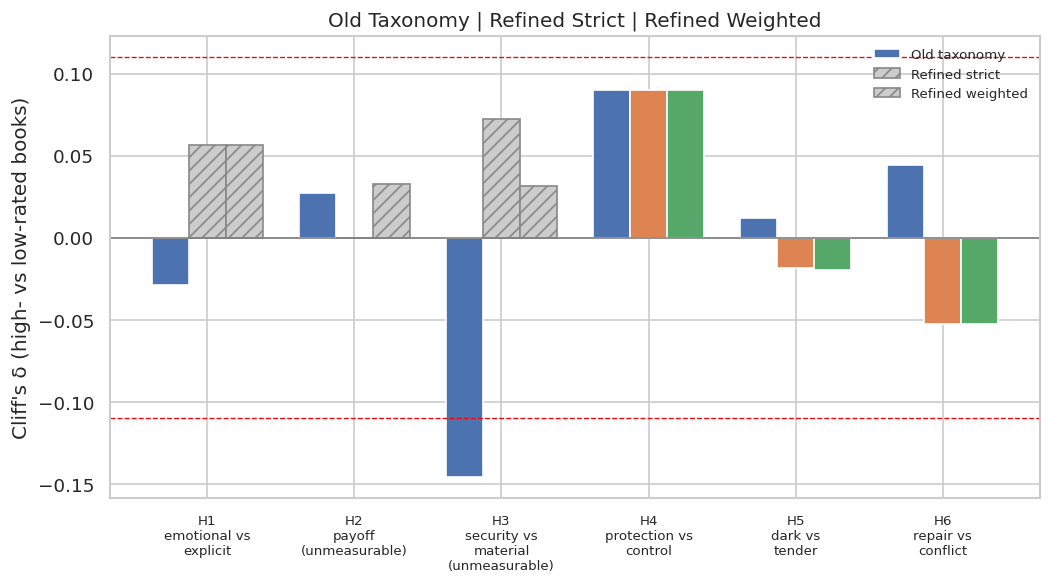

In [5]:
_H_LABELS = {
    "H1": "H1\nemotional vs\nexplicit",
    "H2": "H2\npayoff\n(unmeasurable)",
    "H3": "H3\nsecurity vs\nmaterial\n(unmeasurable)",
    "H4": "H4\nprotection vs\ncontrol",
    "H5": "H5\ndark vs\ntender",
    "H6": "H6\nrepair vs\nconflict",
}
fig, ax = plt.subplots(figsize=(10, 5))
hyps = list(hyp_map.keys())
x = np.arange(len(hyps))
width = 0.25
for i, spec in enumerate(["old_taxonomy", "refined_strict", "refined_weighted"]):
    vals = [wide.loc[h, spec] if h in wide.index and spec in wide.columns else np.nan for h in hyps]
    label = spec.replace("_", " ").capitalize()
    bars = ax.bar(x + (i - 1) * width, vals, width, label=label)
    for h_idx, hyp in enumerate(hyps):
        mgate = compare.loc[
            (compare["hypothesis"] == hyp) & (compare["spec"] == spec), "measurement_gate"
        ]
        if len(mgate) and str(mgate.iloc[0]) in ("unmeasurable", "missing"):
            b = bars[h_idx]
            b.set_hatch("///")
            b.set_facecolor("#cccccc")
            b.set_edgecolor("#888888")
ax.axhline(0, color="gray", lw=1)
ax.axhline(GATE, color="red", ls="--", lw=0.8)
ax.axhline(-GATE, color="red", ls="--", lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels([_H_LABELS.get(h, h) for h in hyps], fontsize=8)
ax.set_ylabel("Cliff's δ (high- vs low-rated books)")
ax.set_title("Old Taxonomy | Refined Strict | Refined Weighted")
ax.legend(loc="upper right", frameon=False, fontsize=8)
ctx.save_figure(fig, "old_vs_refined_bars")
plt.show()

## Sign / magnitude / gate stability

In [6]:
stab = []
for feat in features:
    sub = panel[panel["feature"] == feat]
    if sub.empty:
        continue
    signs = np.sign(sub["cliffs_delta"].dropna())
    stab.append(
        {
            "feature": feat,
            "measurement_gate": nh.gate_for_feature(coverage, feat),
            "n_specs": len(sub),
            "sign_stable": bool(len(set(signs)) <= 1) if len(signs) else False,
            "min_abs_delta": float(sub["cliffs_delta"].abs().min()),
            "max_abs_delta": float(sub["cliffs_delta"].abs().max()),
            "any_clears_gate": bool(
                (
                    (sub["measurement_gate"] != "unmeasurable")
                    & (sub["cliffs_delta"].abs() >= GATE)
                    & ~((sub["ci_low"] <= 0) & (sub["ci_high"] >= 0))
                ).any()
            ),
        }
    )
stab_df = pd.DataFrame(stab)
display(stab_df)
ctx.save_table(stab_df, "stability_summary")

print(
    "Stage 11 complete as measurement-correction analysis. "
    "Stage 10 remains the confirmatory taxonomy baseline."
)

,feature,measurement_gate,n_specs,sign_stable,min_abs_delta,max_abs_delta,any_clears_gate
0,RLR_emotional_vs_explicit,unmeasurable,6,False,0.0076,0.0607,False
1,RAX_h2_strict,unmeasurable,6,False,0.0000,0.0720,False
2,RLR_emotional_vs_material_security,unmeasurable,6,True,0.0315,0.0726,False
3,RLR_protection_vs_control,thin,6,True,0.0898,0.0899,False
4,RLR_darkness_vs_tenderness,thin,6,False,0.0043,0.0755,False
5,RARC,viable,6,True,0.0434,0.0528,False
6,RAX_explicit_sex,unmeasurable,6,True,0.0000,0.0000,False
7,RAX_nonexplicit_affection,thin,6,False,0.0238,0.0579,False
8,RAX_appearance_grooming,viable,6,True,0.1237,0.1424,True
9,RAX_status_display,unmeasurable,6,True,0.0000,0.0000,False


  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/11_refined_robustness/tables/stability_summary.csv  (17 rows)
Stage 11 complete as measurement-correction analysis. Stage 10 remains the confirmatory taxonomy baseline.
